# Personalized Skincare Ingredient Recommendation Engine

## Project Overview

This notebook implements the ingredient-personalization component of the SkinIQ
skincare analysis platform. The platform's existing computer-vision pipeline produces
two diagnostic outputs for a user:

- **Skin type**, one of `Combination`, `Dry`, `Normal`, `Oily`, `Sensitive`
- **Detected skin conditions**, any subset of `acne`, `blackheades`, `dark spots`, `pores`, `wrinkles`

The objective of this notebook is to take these two outputs and produce a personalized
ingredient guide: for every ingredient in the dataset, determine whether it is
**GOOD**, **NEUTRAL**, or **BAD** for that specific user, ranked by relevance.

## Dataset

The ingredient dataset (`ingredientsList.csv`) contains 247 cosmetic ingredients, each
with a short description, a longer functional description, and two structured tag fields:
`who_is_it_good_for` and `who_should_avoid`.

## Methodology

The recommendation engine combines two complementary signals:

1. **Rule-based tag matching.** Diagnostic labels are mapped onto the dataset's tag
   vocabulary. Avoid-tag matches are never overridden by any other signal (safety-first).
   Good-tag matches contribute a proportional score based on how many of the user's
   relevant tags an ingredient satisfies.

2. **Semantic similarity (SBERT).** A natural-language description of the user's profile
   is embedded with a sentence-transformer model and compared against precomputed
   ingredient embeddings. This surfaces relevant ingredients that lack explicit tags and
   provides a secondary ranking signal.

The two signals are blended into a single weighted relevance score. The output for each
profile is three ranked lists: recommended, neutral, and avoid.

## Deliverables

- A reusable `get_personalized_ingredients(skin_type, detected_conditions)` function
- Precomputed embeddings and configuration artifacts for backend integration
- An integration plan for the FastAPI backend and React frontend


## 1. Environment Setup

In [1]:
import ast
import re
import json
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110


## 2. Data Loading and Cleaning

The dataset is loaded from its Kaggle path, with a local fallback for development.
One record with a missing `name` field is dropped and the index is reset to ensure
positional alignment with the embedding matrix.

In [2]:
DATA_PATH = "/kaggle/input/datasets/amaboh/skin-care-product-ingredients-inci-list/ingredientsList.csv"

try:
    df = pd.read_csv(DATA_PATH)
except FileNotFoundError:
    df = pd.read_csv("ingredientsList.csv")

df = df.dropna(subset=["name"]).reset_index(drop=True)

print("Shape:", df.shape)
print()
print(df.isna().sum())
df.head(3)


Shape: (247, 8)

name                    0
scientific_name       247
short_description       0
what_is_it              0
what_does_it_do         0
who_is_it_good_for      0
who_should_avoid        0
url                     0
dtype: int64


,name,scientific_name,short_description,what_is_it,what_does_it_do,who_is_it_good_for,who_should_avoid,url
0,Alpha-Glucan Oligosaccharide,NaN,Alpha-glucan oligosaccharide is in a class of ...,Prebiotics are a type of non-digestible dietar...,Prebiotics offer benefits such as:\r\n\r\n- He...,"[' ', 'Acne', ' ', 'Blackheads', ' ', 'Redness...","[' ', 'Related Allergy']",https://renude.co/ingredients/alpha-glucan-oli...
1,Aloe Vera,NaN,"Aloe vera, also appear on ingredients lists as...",Aloe vera is a skincare ingredient derived fro...,Aloe vera offers multiple benefits for the ski...,"[' ', 'Dry and dehydrated skin', ' ', 'Impaire...","[' ', 'Related Allergy']",https://renude.co/ingredients/aloe-vera
2,Allantoin,NaN,"Allantoin occurs naturally in the body, but ca...",Allantoin is a skincare ingredient derived fro...,"Allantoin is a calming, anti-inflammatory, and...","[' ', 'Fine Lines', ' ', 'Impaired skin barrie...","[' ', 'Related Allergy']",https://renude.co/ingredients/allantoin


## 3. Tag Parsing and Text Preprocessing

The `who_is_it_good_for` and `who_should_avoid` columns are stored as string-encoded
Python lists and are parsed into clean tag lists. A `combined_text` field is built from
the short description and functional descriptions for SBERT input.

In [3]:
def parse_tags(val):
    if pd.isna(val):
        return []
    try:
        items = ast.literal_eval(val)
        return [x.strip() for x in items if x.strip()]
    except (ValueError, SyntaxError):
        return [val.strip()] if val.strip() else []


def clean_text(text):
    if pd.isna(text):
        return ""
    text = re.sub(r"[\r\n]+", " ", text)
    text = re.sub(r"\s{2,}", " ", text)
    return text.strip().lower()


df["good_for_tags"] = df["who_is_it_good_for"].apply(parse_tags)
df["avoid_tags"] = df["who_should_avoid"].apply(parse_tags)

df["combined_text"] = (
    df["short_description"].apply(clean_text) + " " +
    df["what_is_it"].apply(clean_text) + " " +
    df["what_does_it_do"].apply(clean_text)
).str.strip()

print("Sample parsed tags:")
df[["name", "good_for_tags", "avoid_tags"]].head()


Sample parsed tags:


,name,good_for_tags,avoid_tags
0,Alpha-Glucan Oligosaccharide,"[Acne, Blackheads, Redness, Pregnancy]",[Related Allergy]
1,Aloe Vera,"[Dry and dehydrated skin, Impaired skin barrie...",[Related Allergy]
2,Allantoin,"[Fine Lines, Impaired skin barrier, Redness, P...",[Related Allergy]
3,Algin,"[Dry and dehydrated skin, Fine Lines, Pregnanc...",[Related Allergy]
4,Algae Extract,"[Dry and dehydrated skin, Fine Lines, Pregnanc...",[Related Allergy]


## 4. Exploratory Analysis of Ingredient Tags

Examining tag frequencies motivates the mapping decisions in Section 6.

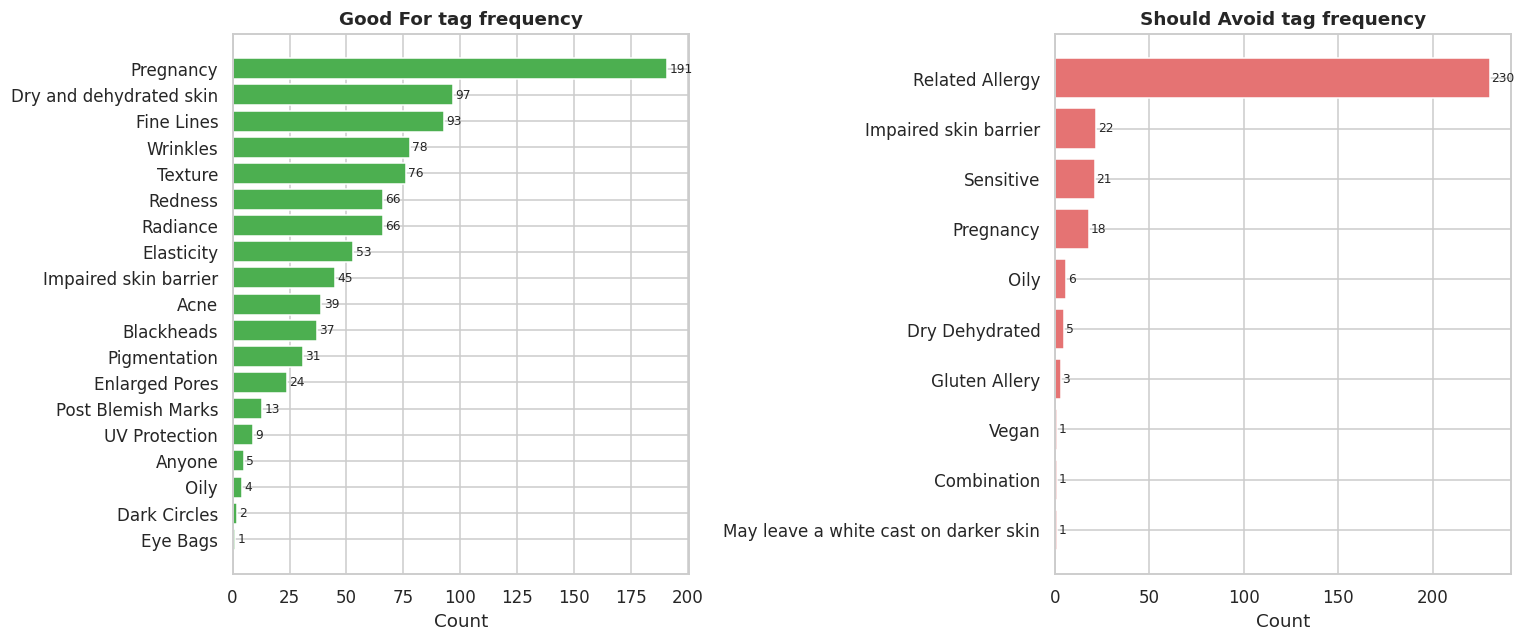

Unique good-for tags: 19
Unique avoid tags:    10


In [4]:
all_good = [t for tags in df["good_for_tags"] for t in tags]
all_avoid = [t for tags in df["avoid_tags"] for t in tags]

good_counts = pd.Series(Counter(all_good)).sort_values(ascending=True)
avoid_counts = pd.Series(Counter(all_avoid)).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(good_counts.index, good_counts.values, color="#4CAF50")
for i, v in enumerate(good_counts.values):
    axes[0].text(v + 1, i, str(v), va="center", fontsize=8)
axes[0].set_title("Good For tag frequency", fontweight="bold")
axes[0].set_xlabel("Count")

axes[1].barh(avoid_counts.index, avoid_counts.values, color="#E57373")
for i, v in enumerate(avoid_counts.values):
    axes[1].text(v + 1, i, str(v), va="center", fontsize=8)
axes[1].set_title("Should Avoid tag frequency", fontweight="bold")
axes[1].set_xlabel("Count")

plt.tight_layout()
plt.show()

print("Unique good-for tags:", len(good_counts))
print("Unique avoid tags:   ", len(avoid_counts))


## 5. Semantic Embeddings

Each ingredient's `combined_text` is encoded once with `all-MiniLM-L6-v2`. These
embeddings are reused for all profiles; only the short profile description needs to
be encoded per request.

In [5]:
sbert = SentenceTransformer("all-MiniLM-L6-v2")

ingredient_texts = df["combined_text"].fillna("").tolist()
ingredient_embeddings = sbert.encode(
    ingredient_texts,
    batch_size=32,
    show_progress_bar=True,
    normalize_embeddings=True
).astype(np.float32)

print("Embedding matrix shape:", ingredient_embeddings.shape)


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/8 [00:00<?, ?it/s]

Embedding matrix shape: (247, 384)


## 6. Personalization Configuration

This section defines all mappings from diagnostic outputs to ingredient tags and
to natural-language descriptions used for semantic matching.

**Excluded tags.**
`Pregnancy`, `Related Allergy`, `Gluten Allery`, `Vegan`, and
`May leave a white cast on darker skin` are excluded from personalization.
`Related Allergy` is present on the majority of ingredients and is not discriminative;
the remaining tags represent information the diagnostic models do not supply.

**Condition mapping.**
Each detected condition maps to two or three relevant good-for tags.

**Skin type mapping.**
Each skin type maps to relevant good-for tags and, separately, to avoid tags.
The avoid mapping for `Sensitive` includes both `Sensitive` and `Impaired skin barrier`,
reflecting that ingredients unsuitable for an impaired barrier (retinoids, high-strength
acids) are generally also unsuitable for sensitive skin.

**Profile descriptions.**
Each skin type and condition has a keyword-dense description concatenated into a single
SBERT query string representing the user's profile.

**Scoring weights.**
The final relevance score for a GOOD ingredient blends the proportion of matched tags
(`TAG_WEIGHT`) with the normalized semantic similarity (`NLP_WEIGHT`).
`NLP_PROMOTE_THRESHOLD` is the minimum normalized semantic similarity required to
promote a tag-less ingredient to GOOD. Section 10 provides the diagnostic histogram
to validate or adjust this value.

In [6]:
EXCLUDE_TAGS = {
    "Pregnancy",
    "Related Allergy",
    "Gluten Allery",
    "Vegan",
    "May leave a white cast on darker skin",
}

UNIVERSAL_GOOD_TAGS = {"Anyone"}

CONDITION_TAG_MAP = {
    "acne":        ["Acne", "Post Blemish Marks"],
    "blackheades": ["Blackheads", "Enlarged Pores"],
    "dark spots":  ["Pigmentation", "Post Blemish Marks", "Radiance"],
    "pores":       ["Enlarged Pores", "Texture"],
    "wrinkles":    ["Wrinkles", "Fine Lines", "Elasticity"],
}

SKIN_TYPE_GOOD_TAG_MAP = {
    "Oily":        ["Oily", "Enlarged Pores"],
    "Dry":         ["Dry and dehydrated skin", "Impaired skin barrier"],
    "Sensitive":   ["Redness", "Impaired skin barrier"],
    "Combination": ["Dry and dehydrated skin", "Oily"],
    "Normal":      ["Radiance", "Fine Lines"],
}

SKIN_TYPE_AVOID_TAG_MAP = {
    "Oily":        ["Oily"],
    "Dry":         ["Dry Dehydrated"],
    "Sensitive":   ["Sensitive", "Impaired skin barrier"],
    "Combination": ["Combination"],
    "Normal":      [],
}

SKIN_TYPE_DESCRIPTIONS = {
    "Oily":        "oily skin excess sebum shine enlarged pores oil control lightweight non-comedogenic mattifying",
    "Dry":         "dry dehydrated skin moisture barrier humectant emollient barrier repair hydration water retention",
    "Normal":      "normal balanced skin gentle maintenance hydration antioxidant protection skin health glow",
    "Sensitive":   "sensitive skin redness irritation reactivity soothing calming anti-inflammatory barrier strengthening low irritation fragrance-free",
    "Combination": "combination skin oily t-zone dry cheeks balancing lightweight hydration gentle oil control",
}

CONDITION_DESCRIPTIONS = {
    "acne":        "acne breakouts anti-acne antibacterial sebum oil controlling anti-inflammatory blemish comedone",
    "blackheades": "blackheads clogged pores comedone exfoliating pore clearing oil balancing keratolytic",
    "dark spots":  "dark spots hyperpigmentation brightening pigmentation reducing antioxidant post blemish marks melanin",
    "pores":       "enlarged pores uneven texture pore refining exfoliating texture smoothing tightening minimizing",
    "wrinkles":    "fine lines wrinkles elasticity anti-aging collagen firming antioxidant retinol peptide renewal",
}

TAG_WEIGHT = 0.65
NLP_WEIGHT = 0.35
NLP_PROMOTE_THRESHOLD = 0.50

SKIN_TYPES = ["Combination", "Dry", "Normal", "Oily", "Sensitive"]
CONDITIONS  = ["acne", "blackheades", "dark spots", "pores", "wrinkles"]

print("Skin types:", SKIN_TYPES)
print("Conditions:", CONDITIONS)


Skin types: ['Combination', 'Dry', 'Normal', 'Oily', 'Sensitive']
Conditions: ['acne', 'blackheades', 'dark spots', 'pores', 'wrinkles']


## 7. Recommendation Function

For every ingredient the engine computes:

- `matched_good_tags` and `matched_avoid_tags`: overlap between the ingredient's tags
  and the user's profile tags
- `tag_good_score`: proportion of the user's good-for tags the ingredient satisfies
- `nlp_score`: min-max normalized SBERT cosine similarity to the profile description

Label assignment:

| Condition | Label | Score formula |
|---|---|---|
| Any avoid tag matches | BAD | fixed `0.0` (rule-only, never overridden) |
| Any good tag matches | GOOD | `TAG_WEIGHT * tag_good_score + NLP_WEIGHT * nlp_score` |
| No tag match, `nlp_score >= threshold` | GOOD | `NLP_WEIGHT * nlp_score` |
| Otherwise | NEUTRAL | `nlp_score` |

Returns three ranked DataFrames capped at `top_n` rows each.

In [7]:
def get_user_profile_tags(skin_type, detected_conditions):
    good = set(SKIN_TYPE_GOOD_TAG_MAP.get(skin_type, [])) | UNIVERSAL_GOOD_TAGS
    avoid = set(SKIN_TYPE_AVOID_TAG_MAP.get(skin_type, []))
    for condition in detected_conditions:
        good |= set(CONDITION_TAG_MAP.get(condition, []))
    good -= EXCLUDE_TAGS
    avoid -= EXCLUDE_TAGS
    return good, avoid


def build_profile_text(skin_type, detected_conditions):
    parts = [SKIN_TYPE_DESCRIPTIONS.get(skin_type, "")]
    for condition in detected_conditions:
        parts.append(CONDITION_DESCRIPTIONS.get(condition, ""))
    return " ".join(part for part in parts if part)


def normalize(arr):
    mn, mx = arr.min(), arr.max()
    return (arr - mn) / (mx - mn + 1e-9)


def get_personalized_ingredients(skin_type, detected_conditions, top_n=15):
    good_tags, avoid_tags = get_user_profile_tags(skin_type, detected_conditions)
    profile_text = build_profile_text(skin_type, detected_conditions)

    query_emb = sbert.encode([profile_text], normalize_embeddings=True)
    nlp_scores = (query_emb @ ingredient_embeddings.T).flatten()
    nlp_n = normalize(nlp_scores)

    n = len(df)
    tag_good_scores  = np.zeros(n)
    avoid_flags      = np.zeros(n, dtype=bool)
    matched_good_col  = [""] * n
    matched_avoid_col = [""] * n

    for i, (good_for, avoid_for) in enumerate(zip(df["good_for_tags"], df["avoid_tags"])):
        ing_good  = set(good_for)  - EXCLUDE_TAGS
        ing_avoid = set(avoid_for) - EXCLUDE_TAGS
        overlap_good  = ing_good  & good_tags
        overlap_avoid = ing_avoid & avoid_tags
        if good_tags:
            tag_good_scores[i] = len(overlap_good) / len(good_tags)
        avoid_flags[i]       = len(overlap_avoid) > 0
        matched_good_col[i]  = ", ".join(sorted(overlap_good))
        matched_avoid_col[i] = ", ".join(sorted(overlap_avoid))

    labels, scores = [], []
    for i in range(n):
        if avoid_flags[i]:
            labels.append("BAD")
            scores.append(0.0)
        elif tag_good_scores[i] > 0:
            labels.append("GOOD")
            scores.append(round(TAG_WEIGHT * tag_good_scores[i] + NLP_WEIGHT * nlp_n[i], 4))
        elif nlp_n[i] >= NLP_PROMOTE_THRESHOLD:
            labels.append("GOOD")
            scores.append(round(NLP_WEIGHT * nlp_n[i], 4))
        else:
            labels.append("NEUTRAL")
            scores.append(round(nlp_n[i], 4))

    results = pd.DataFrame({
        "name":               df["name"].values,
        "label":              labels,
        "score":              scores,
        "matched_good_tags":  matched_good_col,
        "matched_avoid_tags": matched_avoid_col,
        "short_description":  df["short_description"].values,
        "what_does_it_do":    df["what_does_it_do"].values,
        "url":                df["url"].values,
    })

    good    = results[results["label"] == "GOOD"].sort_values("score", ascending=False).head(top_n).reset_index(drop=True)
    neutral = results[results["label"] == "NEUTRAL"].sort_values("score", ascending=False).head(top_n).reset_index(drop=True)
    bad     = results[results["label"] == "BAD"].sort_values("name").reset_index(drop=True)
    return good, neutral, bad


print("get_personalized_ingredients() ready")


get_personalized_ingredients() ready


## 8. Demonstration on Representative Profiles

The function is evaluated on five representative diagnostic outputs covering each
skin type and a range of condition combinations.

In [8]:
EXAMPLE_PROFILES = [
    ("Oily",        ["acne", "pores"]),
    ("Dry",         ["wrinkles", "dark spots"]),
    ("Sensitive",   ["acne"]),
    ("Combination", ["blackheades", "pores"]),
    ("Normal",      ["dark spots"]),
]

for skin_type, conditions in EXAMPLE_PROFILES:
    good, neutral, bad = get_personalized_ingredients(skin_type, conditions, top_n=10)
    header = f"{skin_type} + {', '.join(conditions)}" if conditions else skin_type
    print(f"Profile: {header}")
    print(f"  GOOD: {len(good)}   NEUTRAL: {len(neutral)}   BAD: {len(bad)}")
    print("  Top recommended:")
    for _, row in good.head(5).iterrows():
        tag_info = row["matched_good_tags"] if row["matched_good_tags"] else "semantic match"
        print(f"    {row['name']:32s}  score={row['score']:.3f}  ({tag_info})")
    if len(bad) > 0:
        print("  Avoid:")
        for _, row in bad.head(5).iterrows():
            print(f"    {row['name']:32s}  ({row['matched_avoid_tags']})")
    print()


Profile: Oily + acne, pores
  GOOD: 10   NEUTRAL: 10   BAD: 6
  Top recommended:
    Gluconolactone                    score=0.709  (Acne, Enlarged Pores, Post Blemish Marks, Texture)
    Salicylic Acid                    score=0.706  (Acne, Enlarged Pores, Oily, Post Blemish Marks)
    Polyhydroxy Acids                 score=0.696  (Acne, Enlarged Pores, Post Blemish Marks, Texture)
    Mandelic Acid                     score=0.660  (Acne, Enlarged Pores, Post Blemish Marks, Texture)
    Glycolic Acid                     score=0.651  (Acne, Enlarged Pores, Post Blemish Marks, Texture)
  Avoid:
    Argan Oil                         (Oily)
    Avocado Oil                       (Oily)
    Safflower Seed Oil                (Oily)
    Shea Butter                       (Oily)
    Sunflower Oil                     (Oily)

Profile: Dry + wrinkles, dark spots
  GOOD: 10   NEUTRAL: 10   BAD: 5
  Top recommended:
    Retinol                           score=0.677  (Elasticity, Fine Lines, Pigment

## 9. Label Distribution Across Profiles

Full (uncapped) label distribution for each example profile, to validate that the
engine produces reasonable proportions across all skin types.

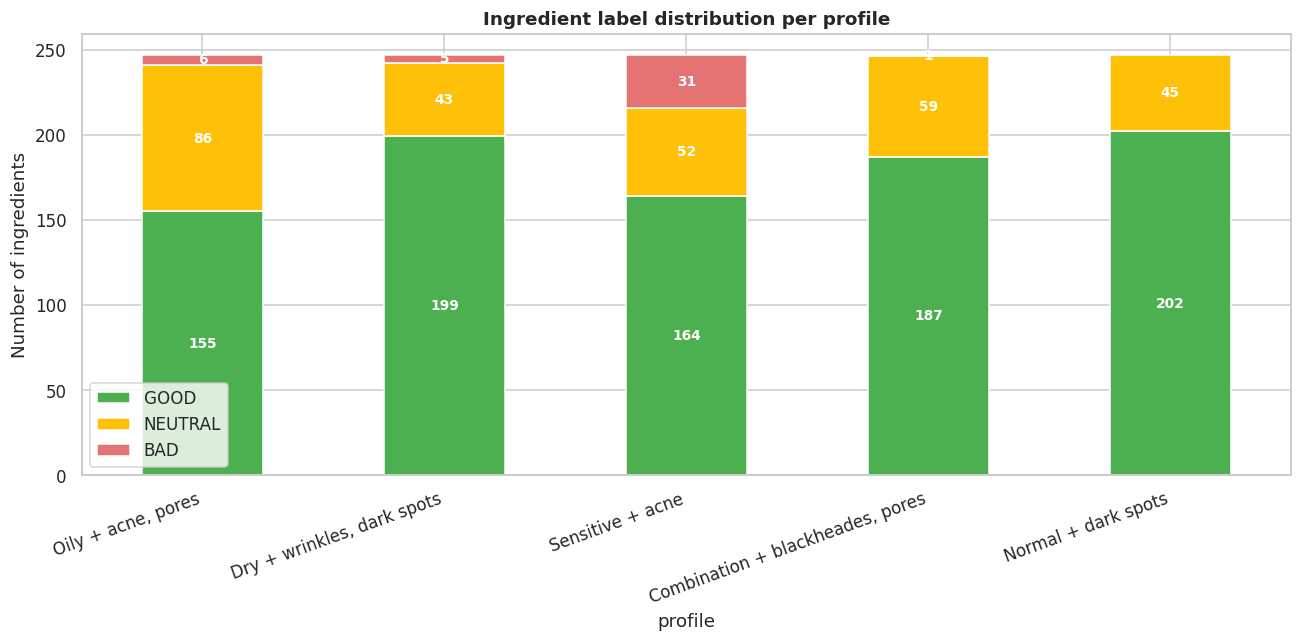

In [9]:
distribution_rows = []
for skin_type, conditions in EXAMPLE_PROFILES:
    good, neutral, bad = get_personalized_ingredients(skin_type, conditions, top_n=len(df))
    label = f"{skin_type} + {', '.join(conditions)}" if conditions else skin_type
    distribution_rows.append({
        "profile": label,
        "GOOD":    len(good),
        "NEUTRAL": len(neutral),
        "BAD":     len(bad),
    })

dist_df = pd.DataFrame(distribution_rows).set_index("profile")

ax = dist_df.plot(
    kind="bar", stacked=True, figsize=(12, 6),
    color=["#4CAF50", "#FFC107", "#E57373"]
)
for container in ax.containers:
    for bar in container:
        h = bar.get_height()
        if h > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_y() + h / 2,
                int(h),
                ha="center", va="center", fontweight="bold", color="white", fontsize=9
            )

ax.set_ylabel("Number of ingredients")
ax.set_title("Ingredient label distribution per profile", fontweight="bold")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


## 10. NLP Promotion Threshold Calibration

The histogram below shows the distribution of normalized SBERT similarity scores for
the Oily + acne + pores profile. The dashed line marks `NLP_PROMOTE_THRESHOLD`.

The number of ingredients above the threshold that do not already have a matching
good tag indicates how many the semantic layer alone promotes to GOOD. If this count
is very large, raise the threshold; if it is near zero, lower it.

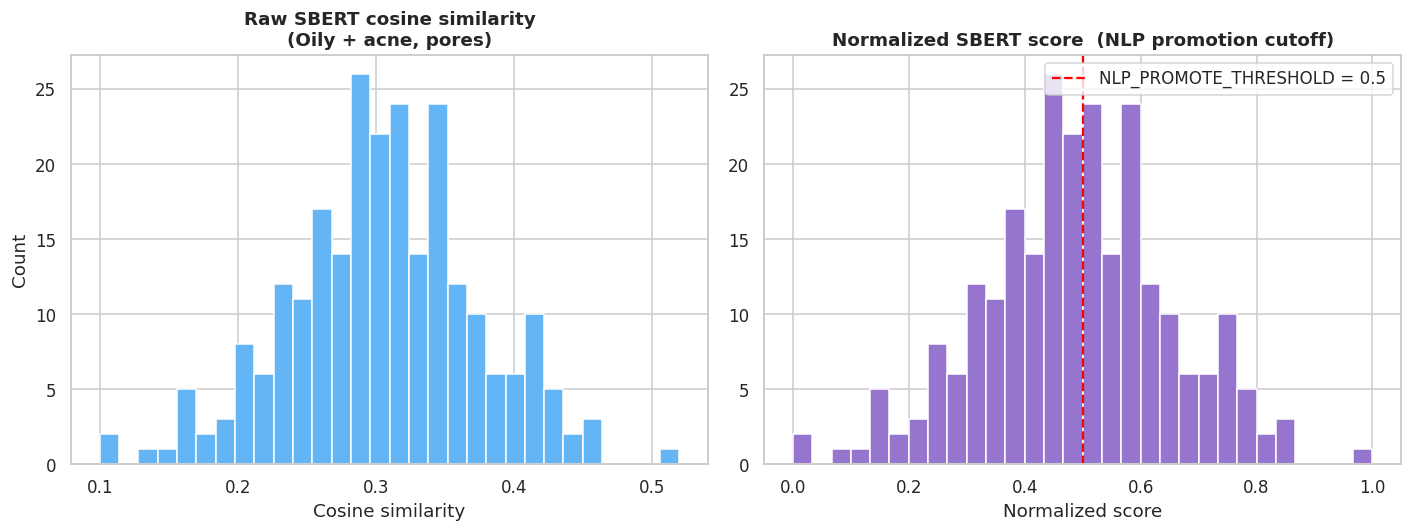

117 / 247 ingredients above NLP_PROMOTE_THRESHOLD = 0.5


In [10]:
_skin_type, _conditions = "Oily", ["acne", "pores"]
_profile_text = build_profile_text(_skin_type, _conditions)

_q_emb = sbert.encode([_profile_text], normalize_embeddings=True)
_raw   = (_q_emb @ ingredient_embeddings.T).flatten()
_norm  = normalize(_raw)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(_raw, bins=30, color="#64B5F6", edgecolor="white")
axes[0].set_title(f"Raw SBERT cosine similarity\n({_skin_type} + {', '.join(_conditions)})", fontweight="bold")
axes[0].set_xlabel("Cosine similarity")
axes[0].set_ylabel("Count")

axes[1].hist(_norm, bins=30, color="#9575CD", edgecolor="white")
axes[1].axvline(NLP_PROMOTE_THRESHOLD, color="red", linestyle="--",
                label=f"NLP_PROMOTE_THRESHOLD = {NLP_PROMOTE_THRESHOLD}")
axes[1].set_title("Normalized SBERT score  (NLP promotion cutoff)", fontweight="bold")
axes[1].set_xlabel("Normalized score")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"{(_norm >= NLP_PROMOTE_THRESHOLD).sum()} / {len(_norm)} ingredients above NLP_PROMOTE_THRESHOLD = {NLP_PROMOTE_THRESHOLD}")


## 11. Detailed Output Inspection

Full column set for one profile — these are the fields the frontend renders
in ingredient cards.

In [11]:
good, neutral, bad = get_personalized_ingredients("Oily", ["acne", "pores"], top_n=10)

print("RECOMMENDED")
display(good[["name", "score", "matched_good_tags", "short_description"]])

print("AVOID")
display(bad[["name", "matched_avoid_tags", "short_description"]])

print("NEUTRAL  (top 5)")
display(neutral[["name", "score", "short_description"]].head(5))


RECOMMENDED


,name,score,matched_good_tags,short_description
0,Gluconolactone,0.7090,"Acne, Enlarged Pores, Post Blemish Marks, Texture",Gluconolactone is a poly hydroxy acid (PHA). P...
1,Salicylic Acid,0.7063,"Acne, Enlarged Pores, Oily, Post Blemish Marks",Salicylic acid works as an exfoliating acid to...
2,Polyhydroxy Acids,0.6960,"Acne, Enlarged Pores, Post Blemish Marks, Texture",Polyhydroxy acids (PHAs) work by gently dissol...
3,Mandelic Acid,0.6601,"Acne, Enlarged Pores, Post Blemish Marks, Texture","Mandelic acid is an alpha hydroxy acid (AHA), ..."
4,Glycolic Acid,0.6514,"Acne, Enlarged Pores, Post Blemish Marks, Texture","Glycolic acid is an alpha hydroxy acid (AHA), ..."
5,Lactobionic Acid,0.5924,"Acne, Enlarged Pores, Post Blemish Marks, Texture",Lactobionic acid is a non-irritating poly hydr...
6,Potassium Azeloyl Diglycinate,0.5645,"Acne, Enlarged Pores, Post Blemish Marks",Potassium Azeloyl Diglycinate (PAD) is a water...
7,Lactic Acid,0.5550,"Acne, Enlarged Pores, Texture","Lactic acid is an alpha hydroxy acid (AHA), wh..."
8,Azelaic Acid,0.5503,"Acne, Enlarged Pores, Post Blemish Marks, Texture",Azelaic acid is found naturally in grains such...
9,Retinol,0.5427,"Acne, Enlarged Pores, Texture","Retinol, is a part of the vitamin A family of ..."


AVOID


,name,matched_avoid_tags,short_description
0,Argan Oil,Oily,Argan oil is derived from the nut of the Argan...
1,Avocado Oil,Oily,"Avocado oil is rich source of fatty acids, it ..."
2,Safflower Seed Oil,Oily,Safflower Seed Oil is derived from the seeds o...
3,Shea Butter,Oily,Shea butter is high in fatty acids and vitamin...
4,Sunflower Oil,Oily,Sunflower oil is a rich natural source of Vita...
5,Sweet Almond Oil,Oily,Sweet Almond Oil is naturally rich in fat-solu...


NEUTRAL  (top 5)


,name,score,short_description
0,Golden-Eye Grass Complex,0.4984,An antioxidant and anti-inflammatory plant ext...
1,Mango Seed Butter,0.4967,"Mango seed butter, also known as mango kernel ..."
2,Caffeine,0.4919,"Caffeine, derived from the coffee plant, is us..."
3,Prickly Pear Extract,0.4906,"Prickly pear is a cactus native to Mexico, and..."
4,Blue Lotus Extract,0.4900,Blue lotus is typically used in skincare for i...


## 12. Export Artifacts

Three artifacts are written to `/kaggle/working` for the production backend:

| File | Contents |
|---|---|
| `ingredient_embeddings.npy` | Precomputed SBERT embedding matrix (247 x 384, float32) |
| `ingredients_data.json` | Per-ingredient display fields (name, descriptions, tags, url) |
| `ingredients_config.json` | All mapping dictionaries, descriptions, and scoring parameters |

At backend startup these files are loaded once. Per request, only the short
profile description is encoded with SBERT; the rest of the computation is
vectorized over the precomputed matrix.

In [12]:
np.save("/kaggle/working/ingredient_embeddings.npy", ingredient_embeddings)

ingredients_data = df[[
    "name", "short_description", "what_does_it_do",
    "good_for_tags", "avoid_tags", "url",
]].to_dict(orient="records")

with open("/kaggle/working/ingredients_data.json", "w") as f:
    json.dump(ingredients_data, f, indent=2)

ingredients_config = {
    "exclude_tags":            sorted(EXCLUDE_TAGS),
    "universal_good_tags":     sorted(UNIVERSAL_GOOD_TAGS),
    "condition_tag_map":       CONDITION_TAG_MAP,
    "skin_type_good_tag_map":  SKIN_TYPE_GOOD_TAG_MAP,
    "skin_type_avoid_tag_map": SKIN_TYPE_AVOID_TAG_MAP,
    "skin_type_descriptions":  SKIN_TYPE_DESCRIPTIONS,
    "condition_descriptions":  CONDITION_DESCRIPTIONS,
    "tag_weight":              TAG_WEIGHT,
    "nlp_weight":              NLP_WEIGHT,
    "nlp_promote_threshold":   NLP_PROMOTE_THRESHOLD,
    "default_top_n":           15,
    "sbert_model":             "all-MiniLM-L6-v2",
    "skin_types":              SKIN_TYPES,
    "conditions":              CONDITIONS,
}

with open("/kaggle/working/ingredients_config.json", "w") as f:
    json.dump(ingredients_config, f, indent=2)

print("Artifacts written to /kaggle/working")
print("  ingredient_embeddings.npy")
print("  ingredients_data.json")
print("  ingredients_config.json")


Artifacts written to /kaggle/working
  ingredient_embeddings.npy
  ingredients_data.json
  ingredients_config.json


## 13. Backend and Frontend Integration Plan

### Backend

1. Copy `ingredient_embeddings.npy`, `ingredients_data.json`, and
   `ingredients_config.json` into `backend/assets/`.

2. Create `backend/ingredients.py`. On module load, initialize a
   `SentenceTransformer("all-MiniLM-L6-v2")` instance, load the embedding matrix
   and config from assets, and expose `get_personalized_ingredients(skin_type,
   detected_conditions, top_n)` using the same logic as Section 7. All mapping
   dictionaries and weights are read from the config file, so tuning the notebook
   and re-exporting is the only step required to update production behavior.

3. Add a new endpoint, for example `GET /api/v1/ingredients`, accepting `skin_type`
   (string) and `conditions` (comma-separated string or list). The endpoint calls
   `get_personalized_ingredients` and returns the structured response below.

4. Add Pydantic schemas:

```python
class IngredientResult(BaseModel):
    name: str
    label: str
    score: float
    matched_good_tags: str
    matched_avoid_tags: str
    short_description: str
    url: str

class IngredientsResponse(BaseModel):
    good: list[IngredientResult]
    neutral: list[IngredientResult]
    bad: list[IngredientResult]
```

### Frontend

On the results page, once the existing skin analysis response is received, call the
ingredients endpoint with `analysis.final_skin_type` and `analysis.detected_conditions`.
Render the result in a new `IngredientsGuide` component with three sections:

- Recommended ingredients (GOOD list, shown by default)
- Ingredients to avoid (BAD list, shown by default)
- Neutral ingredients (collapsed by default, available on expand)

Ingredient cards should display `name`, `short_description`, and link to `url`.
Matched good or avoid tags can be shown as small labels beneath the ingredient name
to provide the user with an explanation of why each ingredient is recommended or flagged.
Reuse the existing card styling from `ConditionCard.jsx` for visual consistency.

### Notes

- `NLP_PROMOTE_THRESHOLD` should be revisited using the Section 10 histogram after
  the notebook is re-executed on Kaggle, since the exact score distribution can shift
  slightly between runs and model versions.
- `Related Allergy` and `Pregnancy` tags are excluded from personalization here but
  could be surfaced as a general patch-test disclaimer elsewhere on the results page.
- Matching a specific product's ingredient list against this dataset would require
  fuzzy or INCI-name matching and is a natural future extension; the exported embeddings
  and ingredient data would be directly reusable for that purpose.
